# Split-and-Delay Bluesky Alignment Validation

This notebook validates the simulator-facing Bluesky/Ophyd integration added in:

- `lcls_beamline_toolbox.models.split_and_delay_ophyd`
- `lcls_beamline_toolbox.utility.bluesky_alignment`

It mirrors the operator-style alignment flow in simulation:

1. create a misaligned split-and-delay model
2. wrap it with the Ophyd adapter
3. run the Phase 1 Bluesky alignment plan
4. run the current Phase 2 Bluesky alignment plan
5. inspect before/after summaries and scan plots

This is intended as a simulator-side validation notebook to share with the team. Hardware-backed validation remains a separate step.

In [5]:
from bluesky import RunEngine
from bluesky.callbacks.best_effort import BestEffortCallback
from IPython.display import display

from lcls_beamline_toolbox.models.split_and_delay_motion import SND
from lcls_beamline_toolbox.models.split_and_delay_ophyd import SndOphyd
from lcls_beamline_toolbox.utility.bluesky_alignment import (
    DEFAULT_PHASE1_STEPS,
    DEFAULT_PHASE2_STEPS,
    align_phase1,
    align_phase2,
    gaussian,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PHASE1_OFFSETS = {
    "t1_th1": 60e-6,
    "t1_th2": -45e-6,
    "t4_th2": 35e-6,
    "t4_th1": -55e-6,
}

PHASE2_OFFSETS = {
    "t1_chi2": 80e-6,
    "t4_chi2": -60e-6,
    "t4_chi1": 50e-6,
}

ALL_OFFSETS = {**PHASE1_OFFSETS, **PHASE2_OFFSETS}

In [6]:
def apply_offsets(snd, offsets):
    for attr, delta in offsets.items():
        getattr(snd, attr).mvr(delta)
    snd.propagate_delay()


def capture_positions(snd, motor_attrs):
    return {motor_attr: getattr(snd, motor_attr).wm() for motor_attr in motor_attrs}


def make_run_engine(with_bec=True):
    RE = RunEngine({})
    if with_bec:
        RE.subscribe(BestEffortCallback())
    return RE


def phase1_summary_df(sequence, initial_positions, final_snd, truth_snd, results):
    rows = []
    for label, motor_attr, detector_attr in sequence:
        truth_position = getattr(truth_snd, motor_attr).wm()
        final_position = getattr(final_snd, motor_attr).wm()
        initial_offset = initial_positions[motor_attr] - truth_position
        final_offset = final_position - truth_position
        rows.append(
            {
                "crystal": label,
                "motor": motor_attr,
                "detector": detector_attr,
                "initial_offset_urad": initial_offset * 1e6,
                "final_offset_urad": final_offset * 1e6,
                "fit_center_urad": results[label]["center"] * 1e6,
                "improved": abs(final_offset) < abs(initial_offset),
            }
        )
    return pd.DataFrame(rows)


def phase2_summary_df(sequence, initial_positions, final_snd, results):
    rows = []
    for label, motor_attr, detector_attr in sequence:
        final_position = getattr(final_snd, motor_attr).wm()
        rows.append(
            {
                "crystal": label,
                "motor": motor_attr,
                "detector": detector_attr,
                "initial_position_urad": initial_positions[motor_attr] * 1e6,
                "final_position_urad": final_position * 1e6,
                "best_position_urad": results[label]["best_position"] * 1e6,
                "best_ip_cy": results[label]["best_signal"],
                "best_vertical_error": results[label]["best_objective"],
            }
        )
    return pd.DataFrame(rows)


def phase2_outcome_df(initial_ip_cy, final_ip_cy, initial_ip_cx, final_ip_cx):
    return pd.DataFrame(
        [
            {
                "initial_ip_cy": initial_ip_cy,
                "final_ip_cy": final_ip_cy,
                "initial_abs_ip_cy": abs(initial_ip_cy),
                "final_abs_ip_cy": abs(final_ip_cy),
                "initial_ip_cx": initial_ip_cx,
                "final_ip_cx": final_ip_cx,
                "reduced_vertical_error": abs(final_ip_cy) < abs(initial_ip_cy),
            }
        ]
    )

## Phase 1 Validation

This section starts from a fixed simulator misalignment, runs the Phase 1 Bluesky plan, and checks that the rocking-curve alignment reduces the motor error relative to a nominal reference model.

/Users/aminelamouchi/Desktop/archive/lcls_beamline_toolbox/lcls_beamline_toolbox/xraywavetrace/optics1d.py:7303: RuntimeWarning: invalid value encountered in scalar divide
  sx = np.sqrt(np.sum(norm_x * (self.x - cx) ** 2) / np.sum(norm_x)) * 1e6
/Users/aminelamouchi/Desktop/archive/lcls_beamline_toolbox/lcls_beamline_toolbox/xraywavetrace/optics1d.py:7304: RuntimeWarning: invalid value encountered in scalar divide
  sy = np.sqrt(np.sum(norm_y * (self.y - cy) ** 2) / np.sum(norm_y)) * 1e6


Before Phase 1 alignment
  t1_dh_sum: 120.947
  dd_sum: 0.133
  t4_dh_sum: 0.000
  do_sum: 0.000


Transient Scan ID: 1     Time: 2026-05-20 13:08:09
Persistent Unique Scan ID: '9d0395ba-ce54-4e91-baed-44befc2e1587'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |     t1_th1 |  t1_dh_sum |
+-----------+------------+------------+------------+
|         1 | 13:08:10.0 |      0.347 |    284.762 |
|         2 | 13:08:10.2 |      0.347 |    326.083 |
|         3 | 13:08:10.3 |      0.347 |    376.474 |
|         4 | 13:08:10.4 |      0.347 |    439.671 |
|         5 | 13:08:10.6 |      0.347 |    521.910 |
|         6 | 13:08:10.7 |      0.347 |    629.263 |
|         7 | 13:08:10.8 |      0.347 |    776.949 |
|         8 | 13:08:11.0 |      0.347 |    985.947 |
|         9 | 13:08:11.1 |      0.347 |   1296.810 |
|        10 | 13:08:11.2 |      0.347 |   1795.524 |
|        11 | 13:08:11.4 |      0.347 |   2718.388 |
|        12 | 13:08:

/Users/aminelamouchi/opt/anaconda3/envs/adaexam/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


|        80 | 13:09:01.8 |      0.347 |    236.356 |
|        81 | 13:09:02.0 |      0.347 |    210.391 |
+-----------+------------+------------+------------+
generator rel_list_scan ['c0b5e755'] (scan num: 4)





,crystal,motor,detector,initial_offset_urad,final_offset_urad,fit_center_urad,improved
0,X1,t1_th1,t1_dh_sum,60.0,0.598125,346782.368779,True
1,X2,t1_th2,dd_sum,-45.0,0.640309,346782.410963,True
2,X3,t4_th2,t4_dh_sum,35.0,0.515745,346782.286399,True
3,X4,t4_th1,do_sum,-55.0,0.547712,346782.318366,True


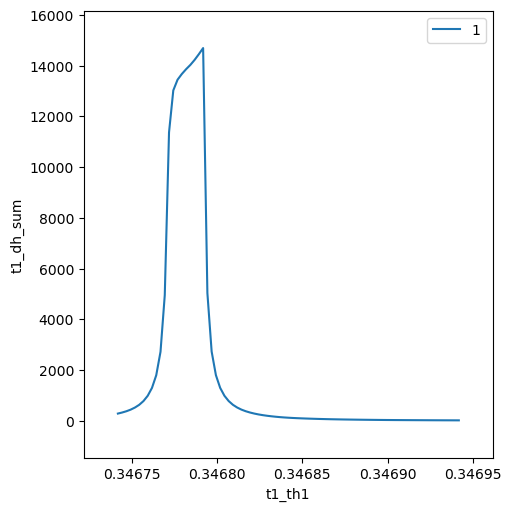

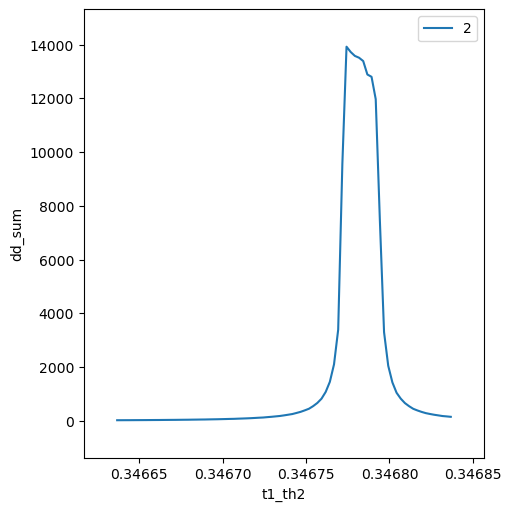

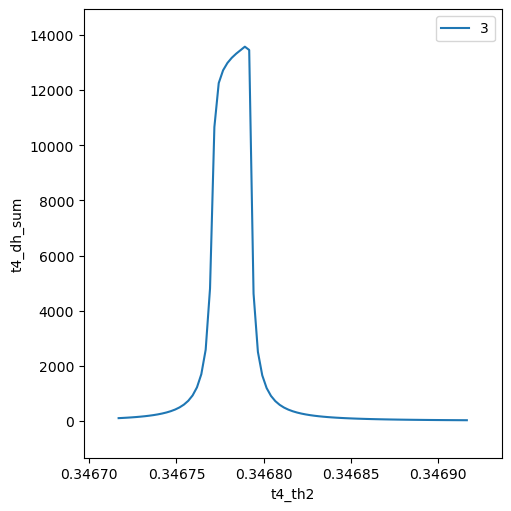

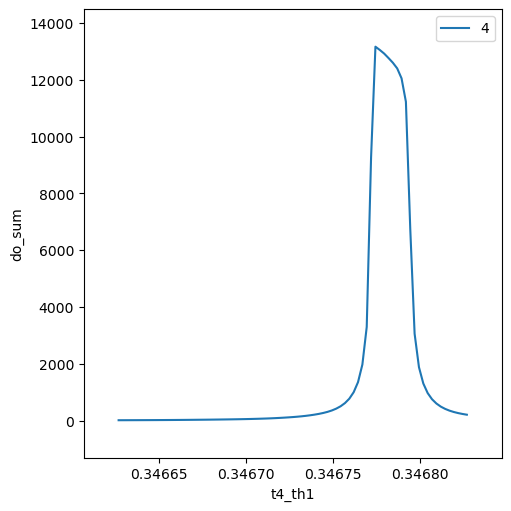

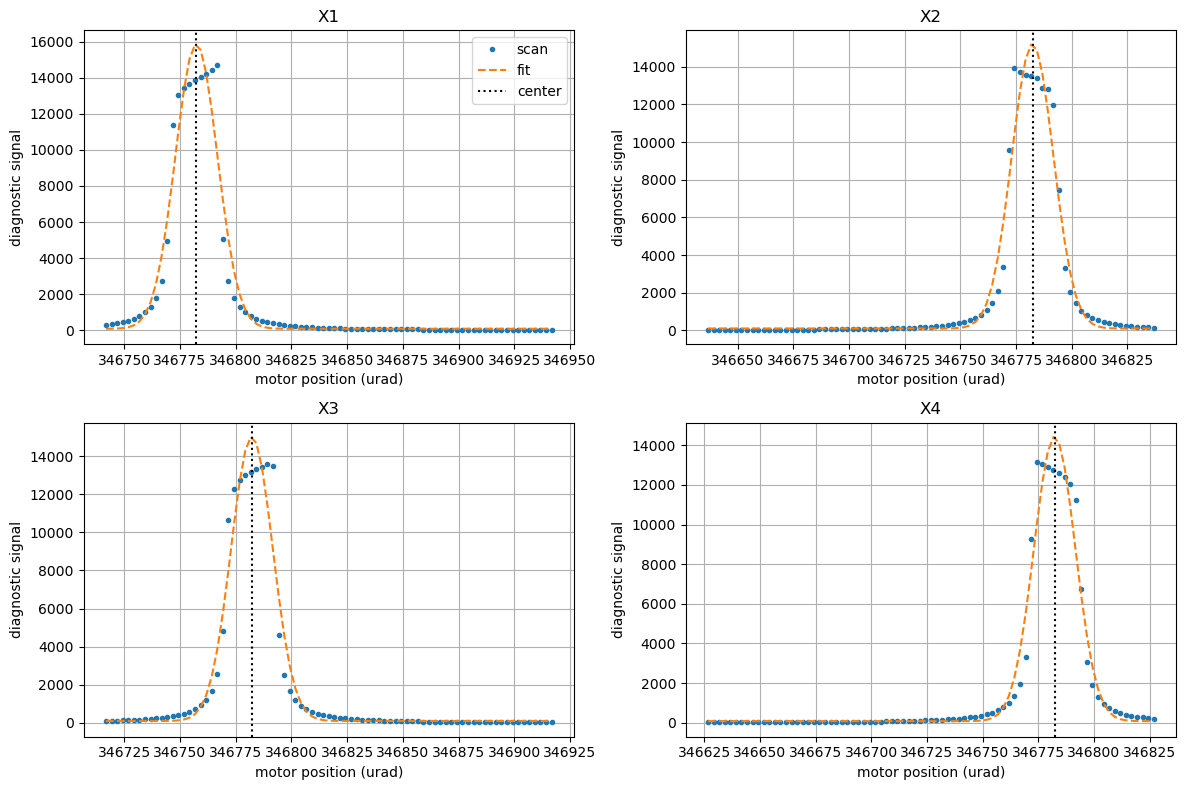

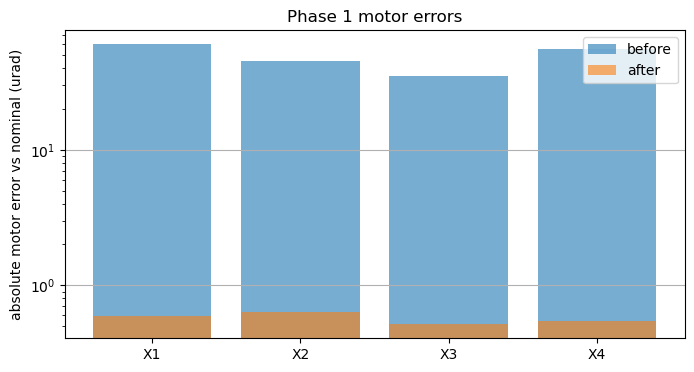

In [7]:
snd_truth = SND(9500)
snd = SND(9500)
apply_offsets(snd, ALL_OFFSETS)

snd_ophyd = SndOphyd(snd)
RE = make_run_engine()

phase1_initial_positions = capture_positions(
    snd,
    [motor_attr for _, motor_attr, _ in DEFAULT_PHASE1_STEPS],
)

print("Before Phase 1 alignment")
for _, detector_attr, getter_name in [
    ("X1", "t1_dh_sum", "get_t1_dh_sum"),
    ("X2", "dd_sum", "get_dd_sum"),
    ("X3", "t4_dh_sum", "get_t4_dh_sum"),
    ("X4", "do_sum", "get_do_sum"),
]:
    print(f"  {detector_attr}: {getattr(snd, getter_name)():.3f}")

phase1_results = align_phase1(
    RE,
    snd_ophyd,
    start=-100e-6,
    stop=100e-6,
    steps=81,
    shots_per_step=1,
)

snd.propagate_delay()
phase1_summary = phase1_summary_df(
    DEFAULT_PHASE1_STEPS,
    phase1_initial_positions,
    snd,
    snd_truth,
    phase1_results,
)

display(phase1_summary)

assert phase1_summary["improved"].all(), "Phase 1 did not improve every rocking motor in simulation."

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (label, _, _) in zip(axes.flat, DEFAULT_PHASE1_STEPS):
    x = phase1_results[label]["x"] * 1e6
    y = phase1_results[label]["y"]
    ax.plot(x, y, ".", label="scan")
    ax.plot(
        x,
        gaussian(
            phase1_results[label]["x"],
            phase1_results[label]["center"],
            phase1_results[label]["sigma"],
            phase1_results[label]["amplitude"],
            phase1_results[label]["yoffset"],
        ),
        "--",
        label="fit",
    )
    ax.axvline(phase1_results[label]["center"] * 1e6, color="k", linestyle=":", label="center")
    ax.set_title(label)
    ax.set_xlabel("motor position (urad)")
    ax.set_ylabel("diagnostic signal")
    ax.grid(True)

axes[0, 0].legend(loc="best")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(phase1_summary["crystal"], np.abs(phase1_summary["initial_offset_urad"]), alpha=0.6, label="before")
plt.bar(phase1_summary["crystal"], np.abs(phase1_summary["final_offset_urad"]), alpha=0.6, label="after")
plt.ylabel("absolute motor error vs nominal (urad)")
plt.title("Phase 1 motor errors")
plt.yscale("log")
plt.grid(True, axis="y")
plt.legend()
plt.show()

## Phase 2 Validation

This section continues from the Phase 1-aligned simulator state and applies the current Phase 2 Bluesky plan. The Phase 2 success criterion in this notebook is reduction of image-plane vertical error, using `IP_cy` as the target diagnostic.

Unlike Phase 1, this section does not treat recovery of nominal chi motor positions as the goal.

Before Phase 2 alignment
  IP_cy: 6.16218e-05
  IP_cx: -1.8448e-08


Transient Scan ID: 5     Time: 2026-05-20 13:09:04
Persistent Unique Scan ID: '716ba8ec-5b49-4917-ae5f-17c616ef387f'


/Users/aminelamouchi/Desktop/archive/lcls_beamline_toolbox/lcls_beamline_toolbox/xraywavetrace/optics1d.py:7303: RuntimeWarning: invalid value encountered in scalar divide
  sx = np.sqrt(np.sum(norm_x * (self.x - cx) ** 2) / np.sum(norm_x)) * 1e6
/Users/aminelamouchi/Desktop/archive/lcls_beamline_toolbox/lcls_beamline_toolbox/xraywavetrace/optics1d.py:7304: RuntimeWarning: invalid value encountered in scalar divide
  sy = np.sqrt(np.sum(norm_y * (self.y - cy) ** 2) / np.sum(norm_y)) * 1e6


New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |    t1_chi2 |      IP_cy |
+-----------+------------+------------+------------+
|         1 | 13:09:04.4 |     -0.000 |      0.000 |
|         2 | 13:09:04.6 |     -0.000 |      0.000 |
|         3 | 13:09:04.7 |     -0.000 |      0.000 |
|         4 | 13:09:04.9 |     -0.000 |      0.000 |
|         5 | 13:09:05.1 |     -0.000 |      0.000 |
|         6 | 13:09:05.2 |     -0.000 |      0.000 |
|         7 | 13:09:05.4 |     -0.000 |      0.000 |
|         8 | 13:09:05.5 |     -0.000 |      0.000 |
|         9 | 13:09:05.7 |      0.000 |      0.000 |
|        10 | 13:09:05.8 |      0.000 |      0.000 |
|        11 | 13:09:06.0 |      0.000 |      0.000 |
|        12 | 13:09:06.1 |      0.000 |      0.000 |
|        13 | 13:09:06.2 |      0.000 |      0.000 |
|        14 | 13:09:06.4 |      0.000 |      0.000 |
|        15 | 13:09:06.5 |      0.000 |      0.000 |
|        16 | 13:09:06.7

,crystal,motor,detector,initial_position_urad,final_position_urad,best_position_urad,best_ip_cy,best_vertical_error
0,X2,t1_chi2,IP_cy,80.0,110.0,110.0,0.000001,0.000001
1,X3,t4_chi2,IP_cy,-60.0,-60.0,-60.0,0.000001,0.000001
2,X4,t4_chi1,IP_cy,50.0,50.0,50.0,0.000001,0.000001


,initial_ip_cy,final_ip_cy,initial_abs_ip_cy,final_abs_ip_cy,initial_ip_cx,final_ip_cx,reduced_vertical_error
0,0.000062,0.000001,0.000062,0.000001,-1.844797e-08,1.590173e-08,True


After Phase 2 alignment
  IP_cy: 1.09808e-06
  IP_cx: 1.59017e-08


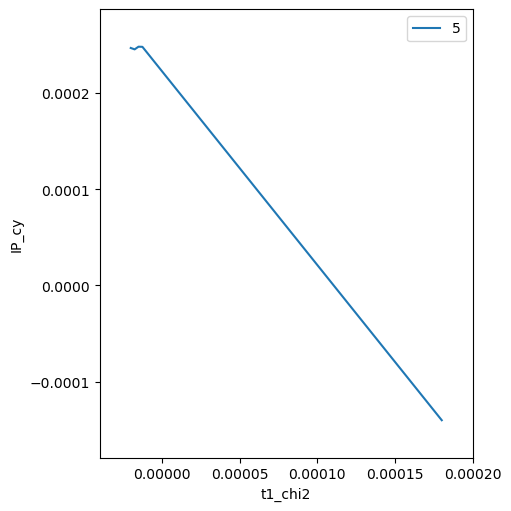

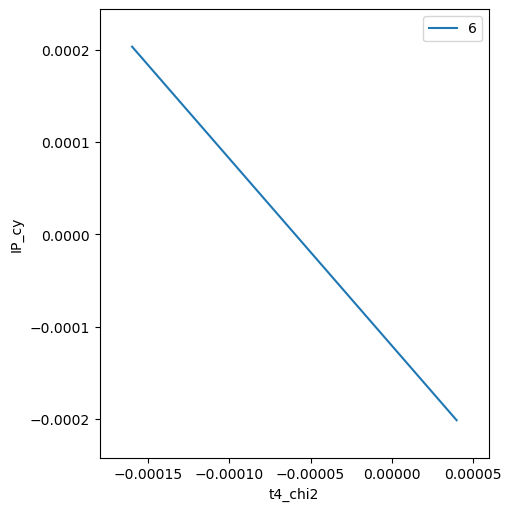

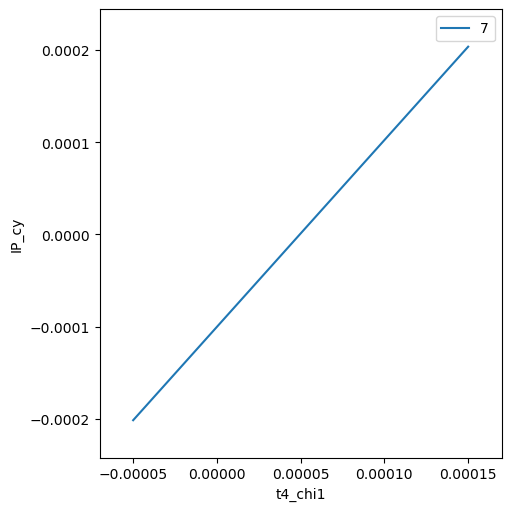

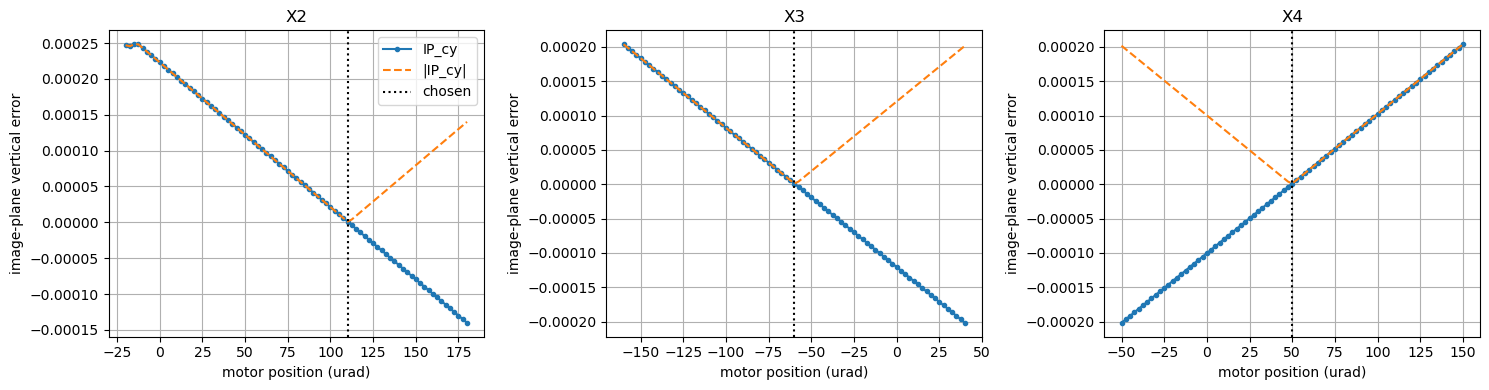

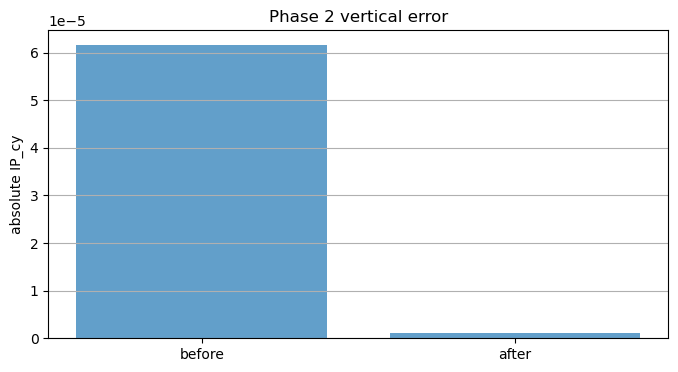

In [8]:
phase2_initial_positions = capture_positions(
    snd,
    [motor_attr for _, motor_attr, _ in DEFAULT_PHASE2_STEPS],
)
phase2_initial_ip_cy = snd.get_IP_cy()
phase2_initial_ip_cx = snd.get_IP_cx()

print("Before Phase 2 alignment")
print(f"  IP_cy: {phase2_initial_ip_cy:.6g}")
print(f"  IP_cx: {phase2_initial_ip_cx:.6g}")

phase2_results = align_phase2(
    RE,
    snd_ophyd,
    start=-100e-6,
    stop=100e-6,
    steps=81,
    shots_per_step=1,
)

snd.propagate_delay()
phase2_final_ip_cy = snd.get_IP_cy()
phase2_final_ip_cx = snd.get_IP_cx()

phase2_summary = phase2_summary_df(
    DEFAULT_PHASE2_STEPS,
    phase2_initial_positions,
    snd,
    phase2_results,
)
phase2_outcome = phase2_outcome_df(
    phase2_initial_ip_cy,
    phase2_final_ip_cy,
    phase2_initial_ip_cx,
    phase2_final_ip_cx,
)

display(phase2_summary)
display(phase2_outcome)

print("After Phase 2 alignment")
print(f"  IP_cy: {phase2_final_ip_cy:.6g}")
print(f"  IP_cx: {phase2_final_ip_cx:.6g}")

assert phase2_outcome.loc[0, "reduced_vertical_error"], (
    "Phase 2 did not reduce the absolute vertical image-plane error in simulation."
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, _, _) in zip(axes.flat, DEFAULT_PHASE2_STEPS):
    x = phase2_results[label]["x"] * 1e6
    y = phase2_results[label]["y"]
    objective = phase2_results[label]["objective_y"]

    ax.plot(x, y, ".-", label="IP_cy")
    ax.plot(x, objective, "--", label="|IP_cy|")
    ax.axvline(phase2_results[label]["best_position"] * 1e6, color="k", linestyle=":", label="chosen")
    ax.set_title(label)
    ax.set_xlabel("motor position (urad)")
    ax.set_ylabel("image-plane vertical error")
    ax.grid(True)

axes[0].legend(loc="best")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(["before", "after"], [abs(phase2_initial_ip_cy), abs(phase2_final_ip_cy)], alpha=0.7)
plt.ylabel("absolute IP_cy")
plt.title("Phase 2 vertical error")
plt.grid(True, axis="y")
plt.show()